# Previsão de Churn e Retenção Estratégica de Clientes
**Equipe:** Bruno Fernandes, Diogo Palharini, Erika Ribeiro, Jonas Ribeiro  
**Algoritmo:** Random Forest — Classificação Binária  
**Dataset:** Telco Customer Churn (IBM / Kaggle)

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
)
from sklearn.utils import resample

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

## 1. Carregamento dos Dados
Dataset **Telco Customer Churn** — IBM/Kaggle. Contém 7.043 clientes de uma operadora de telecomunicações, com 20 features comportamentais, demográficas e contratuais, e o target `Churn` (Yes/No).

In [102]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Qualidade dos Dados

In [103]:
print(f'Linhas duplicadas: {df.duplicated().sum()}')

null_summary = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% Total': (df.isnull().sum() / len(df) * 100).round(2),
    'Tipo': df.dtypes
})
print('\nResumo de nulos:')
null_summary[null_summary['Nulos'] > 0]

Linhas duplicadas: 0

Resumo de nulos:


,Nulos,% Total,Tipo
TotalCharges,11,0.16,float64


In [104]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print('Nulos após preenchimento:', df.isnull().sum().sum())

Nulos após preenchimento: 0


## 3. Análise Exploratória (EDA)

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [106]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2281.916928,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2265.270398,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,402.225000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


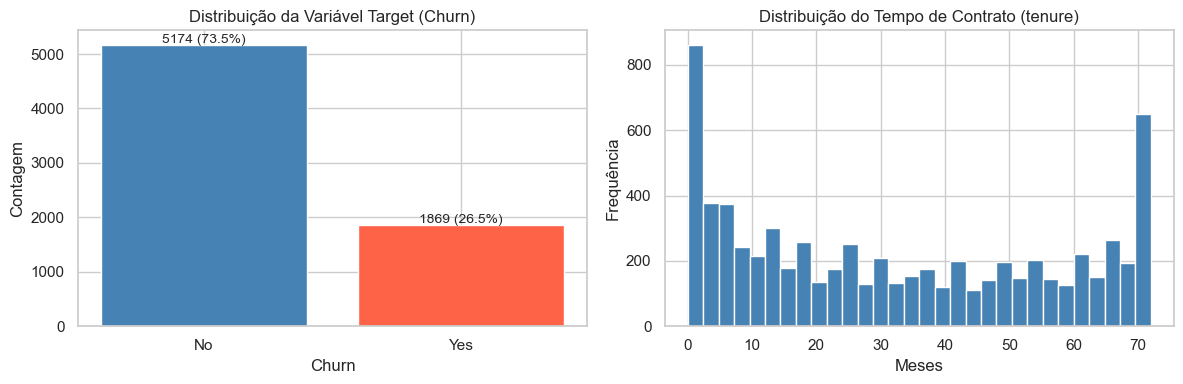

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribuição da Variável Target (Churn)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

axes[1].hist(df['tenure'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribuição do Tempo de Contrato (tenure)')
axes[1].set_xlabel('Meses')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('eda_target_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

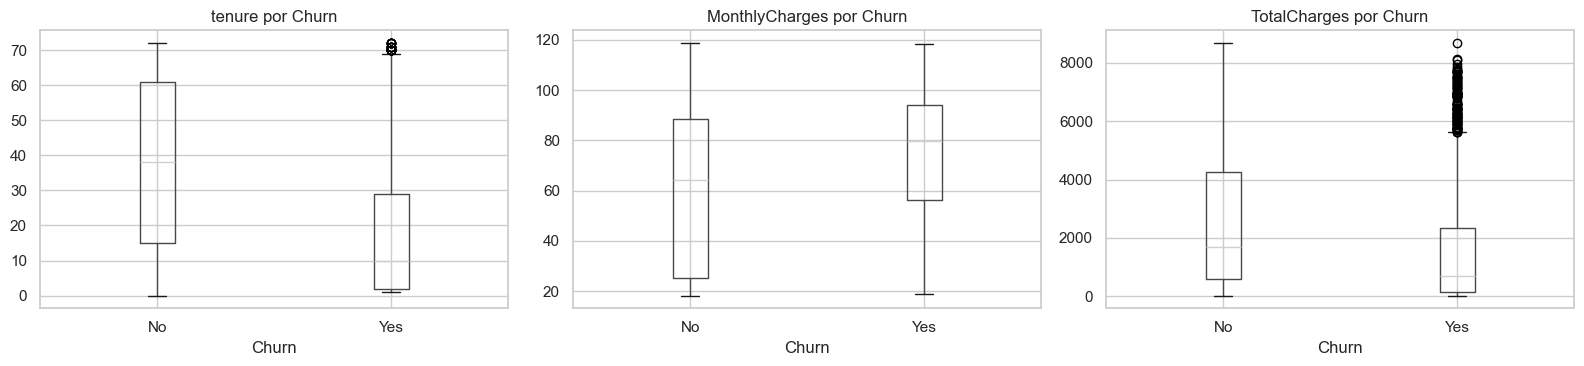

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
num_cols_eda = ['tenure', 'MonthlyCharges', 'TotalCharges']
for ax, col in zip(axes, num_cols_eda):
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} por Churn')
    ax.set_xlabel('Churn')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\jonas\AppData\Local\Temp\ipykernel_22272\3339804399.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_enc_corr.select_dtypes(include='object').columns:


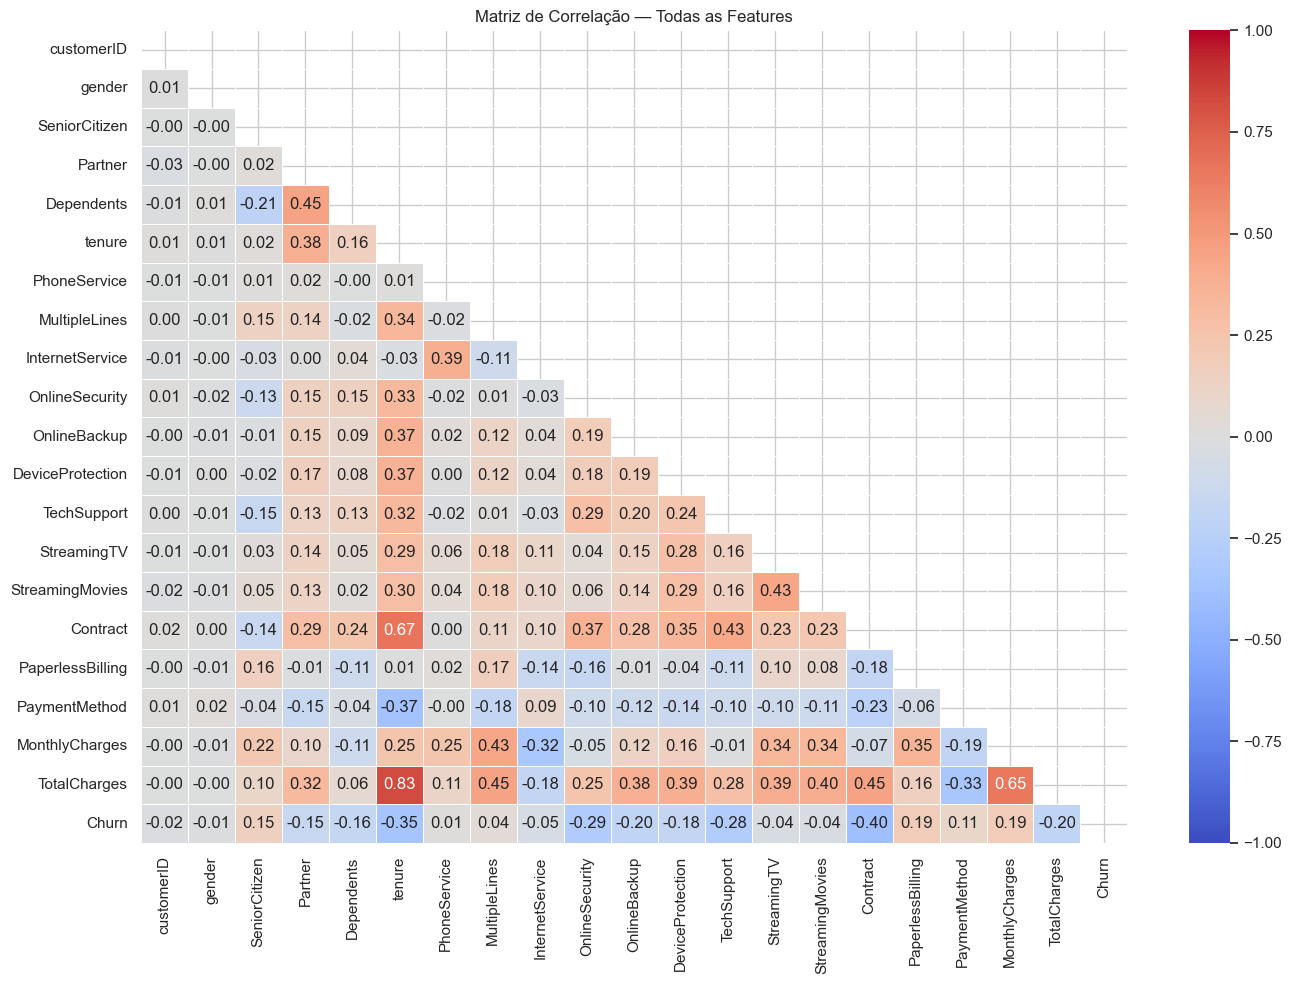

In [109]:
df_enc_corr = df.copy()
le_tmp = LabelEncoder()
for col in df_enc_corr.select_dtypes(include='object').columns:
    df_enc_corr[col] = le_tmp.fit_transform(df_enc_corr[col].astype(str))

numeric_cols = df_enc_corr.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_enc_corr[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Matriz de Correlação — Todas as Features')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

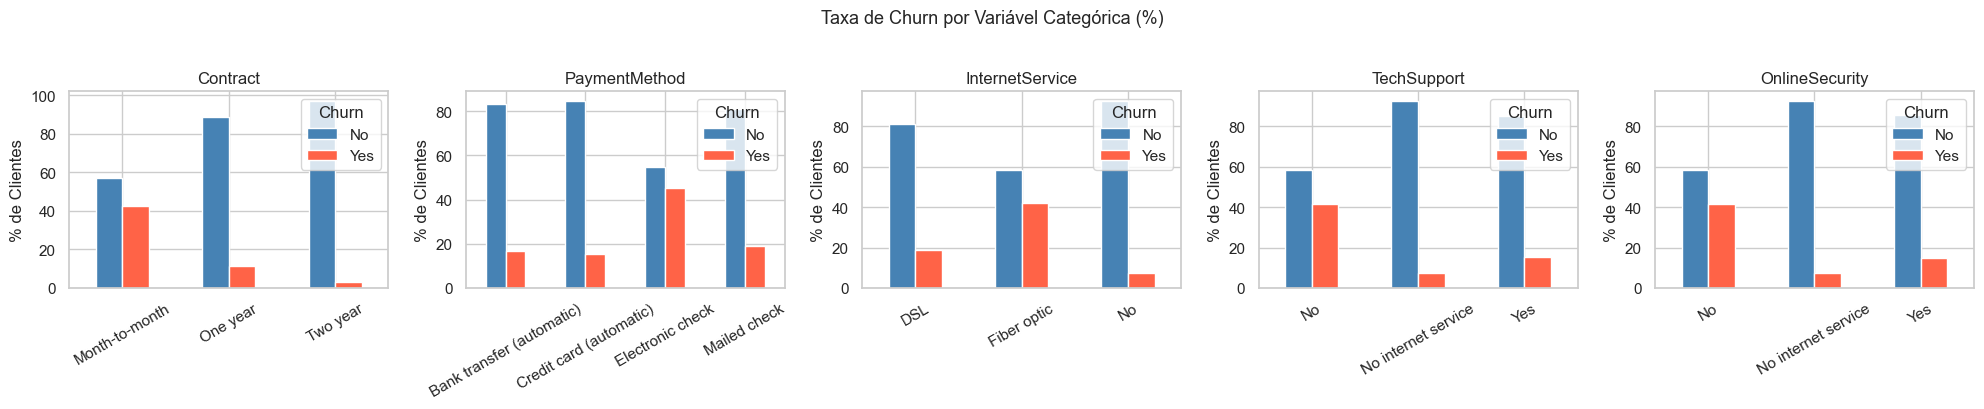

In [110]:
cat_features = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']
fig, axes = plt.subplots(1, len(cat_features), figsize=(20, 4))
for ax, feat in zip(axes, cat_features):
    ct = pd.crosstab(df[feat], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(feat)
    ax.set_ylabel('% de Clientes')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Churn', loc='upper right')
plt.suptitle('Taxa de Churn por Variável Categórica (%)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda_categorical_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Detecção e Tratamento de Outliers (IQR Winsorizing)

In [111]:
NUM_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges']

outlier_report = []
for col in NUM_FEATURES:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({
        'Feature': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'IQR': round(IQR, 2), 'Limite Inf.': round(lower, 2),
        'Limite Sup.': round(upper, 2), 'Outliers': n_out
    })

pd.DataFrame(outlier_report).set_index('Feature')

,Q1,Q3,IQR,Limite Inf.,Limite Sup.,Outliers
Feature,,,,,,
tenure,9.00,55.00,46.00,-60.00,124.00,0
MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0
TotalCharges,402.22,3786.60,3384.38,-4674.34,8863.16,0


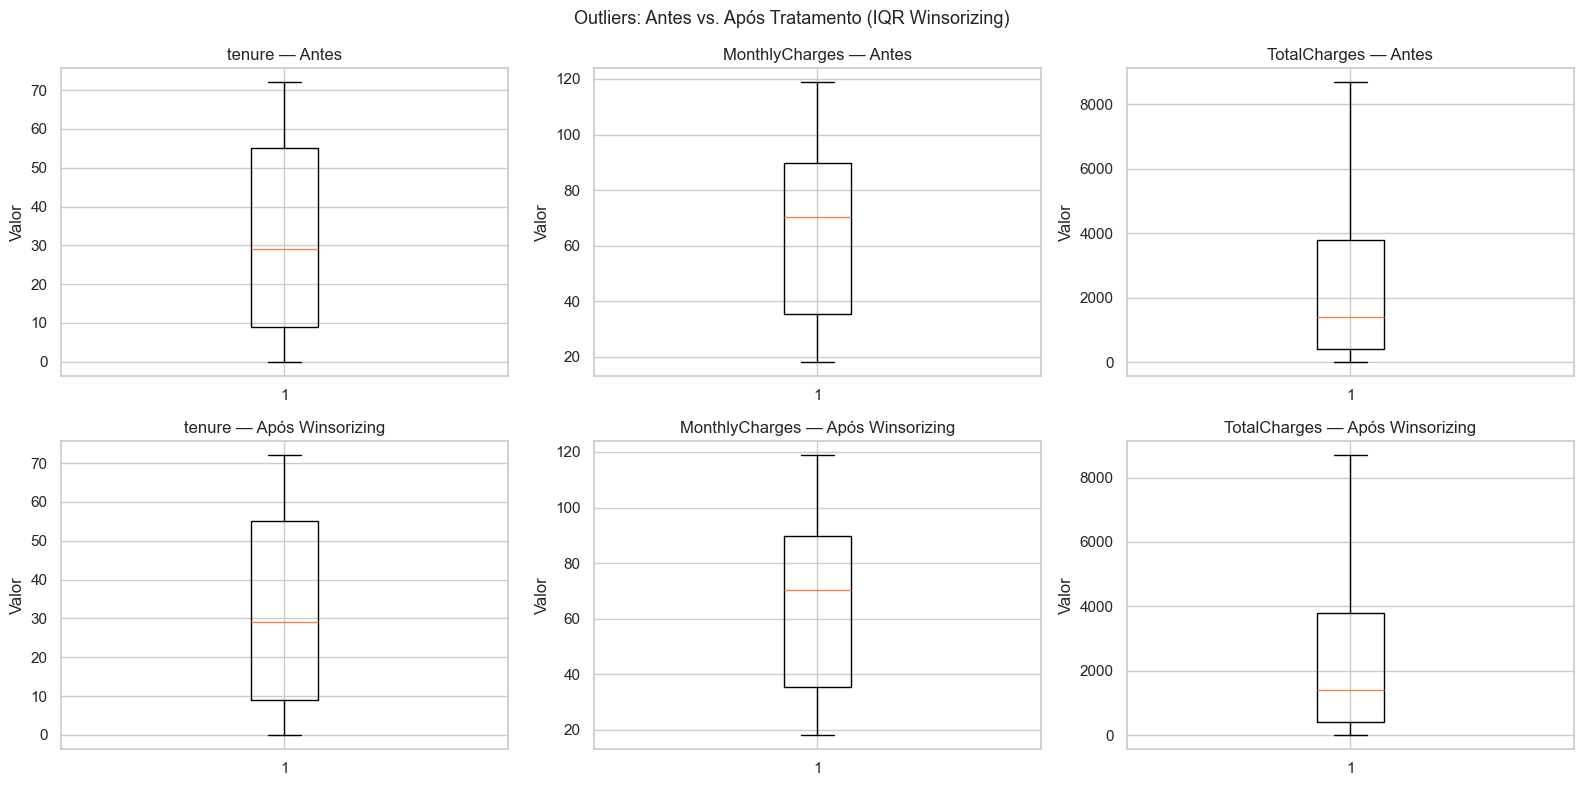

In [112]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

df_capped = df.copy()
for i, col in enumerate(NUM_FEATURES):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    axes[0, i].boxplot(df[col].dropna())
    axes[0, i].set_title(f'{col} — Antes')
    axes[0, i].set_ylabel('Valor')

    df_capped[col] = df[col].clip(lower=lower, upper=upper)

    axes[1, i].boxplot(df_capped[col].dropna())
    axes[1, i].set_title(f'{col} — Após Winsorizing')
    axes[1, i].set_ylabel('Valor')

plt.suptitle('Outliers: Antes vs. Após Tratamento (IQR Winsorizing)', fontsize=13)
plt.tight_layout()
plt.savefig('outliers_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

df = df_capped.copy()

## 5. Feature Engineering

ChargesPerMonth — Limite Superior IQR: 172.94
Outliers antes do cap: 11  |  Max antes: 1397.47


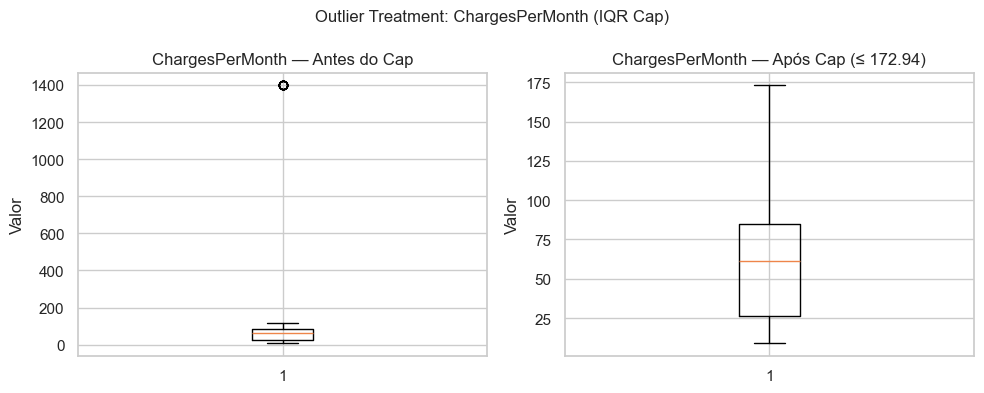


Outliers após cap: 0  |  Max após: 172.94

Estatísticas finais das features criadas:


,ChargesPerMonth,NumStreamingServices,NumOnlineServices,NumTotalServices,IsNewCustomer,HasNoProtection
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,59.26,0.77,1.27,2.04,0.21,0.36
std,30.82,0.85,1.29,1.85,0.41,0.48
min,9.18,0.00,0.00,0.00,0.00,0.00
25%,26.27,0.00,0.00,0.00,0.00,0.00
50%,61.15,0.00,1.00,2.00,0.00,0.00
75%,84.94,2.00,2.00,3.00,0.00,1.00
max,172.94,2.00,4.00,6.00,1.00,1.00


In [113]:
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

streaming_cols = ['StreamingTV', 'StreamingMovies']
online_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

df['NumStreamingServices'] = df[streaming_cols].apply(lambda r: (r == 'Yes').sum(), axis=1)
df['NumOnlineServices'] = df[online_cols].apply(lambda r: (r == 'Yes').sum(), axis=1)
df['NumTotalServices'] = df['NumStreamingServices'] + df['NumOnlineServices']

df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

df['HasNoProtection'] = (
    (df['OnlineSecurity'] == 'No') &
    (df['InternetService'] != 'No') &
    (df['TechSupport'] == 'No')
).astype(int)

Q1_cpm = df['ChargesPerMonth'].quantile(0.25)
Q3_cpm = df['ChargesPerMonth'].quantile(0.75)
IQR_cpm = Q3_cpm - Q1_cpm
upper_cpm = Q3_cpm + 1.5 * IQR_cpm

n_before = (df['ChargesPerMonth'] > upper_cpm).sum()
print(f'ChargesPerMonth — Limite Superior IQR: {upper_cpm:.2f}')
print(f'Outliers antes do cap: {n_before}  |  Max antes: {df["ChargesPerMonth"].max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['ChargesPerMonth'].dropna())
axes[0].set_title('ChargesPerMonth — Antes do Cap')
axes[0].set_ylabel('Valor')

df['ChargesPerMonth'] = df['ChargesPerMonth'].clip(upper=upper_cpm)

axes[1].boxplot(df['ChargesPerMonth'].dropna())
axes[1].set_title(f'ChargesPerMonth — Após Cap (≤ {upper_cpm:.2f})')
axes[1].set_ylabel('Valor')

plt.suptitle('Outlier Treatment: ChargesPerMonth (IQR Cap)', fontsize=12)
plt.tight_layout()
plt.savefig('outlier_chargespermonth.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOutliers após cap: {(df["ChargesPerMonth"] > upper_cpm).sum()}  |  Max após: {df["ChargesPerMonth"].max():.2f}')
print('\nEstatísticas finais das features criadas:')
df[['ChargesPerMonth', 'NumStreamingServices', 'NumOnlineServices',
    'NumTotalServices', 'IsNewCustomer', 'HasNoProtection']].describe().round(2)

## 6. Pré-processamento e Codificação

In [114]:
df_model = df.drop(columns=['customerID'])

df_model['SeniorCitizen'] = df_model['SeniorCitizen'].astype(int)

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=False)

bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print('Shape após pré-processamento:', df_model.shape)
df_model.head(3)

Shape após pré-processamento: (7043, 47)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,ChargesPerMonth,NumStreamingServices,NumOnlineServices,NumTotalServices,IsNewCustomer,HasNoProtection,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,14.925000,0,1,1,1,1,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,53.985714,0,2,2,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,36.050000,0,2,2,1,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1


## 7. Divisão Treino / Teste

In [115]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print('\nDistribuição no treino:')
print(y_train.value_counts(normalize=True).rename({0: 'Fica (0)', 1: 'Sai (1)'}))

Treino: 5282 amostras | Teste: 1761 amostras

Distribuição no treino:
Churn
Fica (0)    0.73457
Sai (1)     0.26543
Name: proportion, dtype: float64


## 8. Normalização (RobustScaler)
RobustScaler usa mediana e IQR — resistente aos outliers residuais após winsorizing.  
Aplicado **somente ao treino** (fit) e replicado no teste (transform) para evitar **data leakage**.

In [116]:
SCALE_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth',
              'NumStreamingServices', 'NumOnlineServices', 'NumTotalServices']

scaler = RobustScaler()
X_train[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test[SCALE_COLS] = scaler.transform(X_test[SCALE_COLS])

print('Estatísticas após normalização (treino):')
X_train[SCALE_COLS].describe().round(3)

Estatísticas após normalização (treino):


,tenure,MonthlyCharges,TotalCharges,ChargesPerMonth,NumStreamingServices,NumOnlineServices,NumTotalServices
count,5282.000,5282.000,5282.000,5282.000,5282.000,5282.000,5282.000
mean,0.072,-0.103,0.263,-0.034,0.390,0.139,0.020
std,0.527,0.553,0.663,0.523,0.429,0.645,0.620
min,-0.620,-0.955,-0.398,-0.879,0.000,-0.500,-0.667
25%,-0.428,-0.643,-0.288,-0.594,0.000,-0.500,-0.667
50%,0.000,0.000,-0.000,0.000,0.000,0.000,0.000
75%,0.572,0.357,0.712,0.406,1.000,0.500,0.333
max,0.920,0.885,2.118,1.888,1.000,1.500,1.333


## 9. Balanceamento de Classes (SMOTE)

In [117]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Distribuição após SMOTE:')
print(pd.Series(y_train_bal).value_counts())
print(f'\nAmostras sintéticas geradas: {int(y_train_bal.sum()) - int(y_train.sum())}')

Distribuição após SMOTE:
Churn
0    3880
1    3880
Name: count, dtype: int64

Amostras sintéticas geradas: 2478


## 9.5. Otimização de Hiperparâmetros (RandomizedSearchCV)

In [118]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [8, 10, 12, 15, None],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2'],
}

rf_search = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)
search = RandomizedSearchCV(
    rf_search, param_dist,
    n_iter=40, cv=3, scoring='roc_auc',
    random_state=SEED, n_jobs=-1, verbose=0
)
search.fit(X_train_bal, y_train_bal)

print('Melhores hiperparâmetros:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nROC-AUC médio (CV 3-fold): {search.best_score_:.4f}')

Melhores hiperparâmetros:
  n_estimators: 200
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: log2
  max_depth: None

ROC-AUC médio (CV 3-fold): 0.9109


## 10. Modelagem — Random Forest

In [119]:
rf = search.best_estimator_
print('Modelo: hiperparâmetros otimizados via RandomizedSearchCV')
print(f'ROC-AUC médio (CV): {search.best_score_:.4f}')
print('\nParâmetros:')
for k, v in rf.get_params().items():
    if k in search.best_params_:
        print(f'  {k}: {v}')

Modelo: hiperparâmetros otimizados via RandomizedSearchCV
ROC-AUC médio (CV): 0.9109

Parâmetros:
  max_depth: None
  max_features: log2
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 200


## 11. Diagnóstico do Modelo

In [120]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=['Fica (0)', 'Sai (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

=== Relatório de Classificação ===
              precision    recall  f1-score   support

    Fica (0)       0.87      0.81      0.84      1294
     Sai (1)       0.56      0.67      0.61       467

    accuracy                           0.77      1761
   macro avg       0.72      0.74      0.72      1761
weighted avg       0.79      0.77      0.78      1761

ROC-AUC: 0.8337


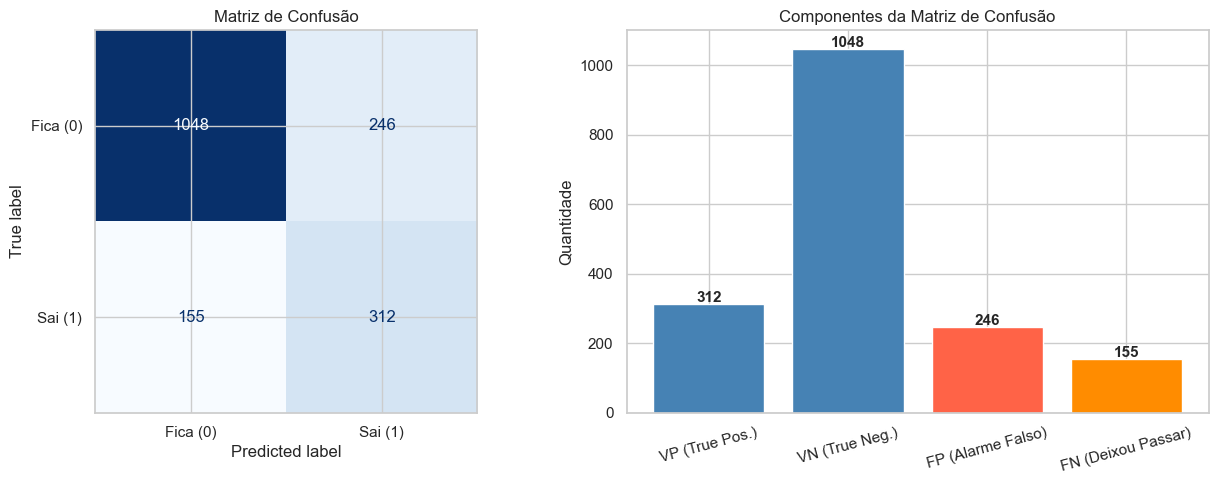


Falsos Negativos (clientes que iriam sair, não detectados): 155
Falsos Positivos (alarmes falsos enviados à retenção): 246


In [121]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fica (0)', 'Sai (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão')

tn, fp, fn, tp = cm.ravel()
metrics = {
    'VP (True Pos.)': tp,
    'VN (True Neg.)': tn,
    'FP (Alarme Falso)': fp,
    'FN (Deixou Passar)': fn
}
colors = ['steelblue', 'steelblue', 'tomato', 'darkorange']
axes[1].bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white')
axes[1].set_title('Componentes da Matriz de Confusão')
axes[1].set_ylabel('Quantidade')
for i, (k, v) in enumerate(metrics.items()):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('diagnostico_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFalsos Negativos (clientes que iriam sair, não detectados): {fn}')
print(f'Falsos Positivos (alarmes falsos enviados à retenção): {fp}')

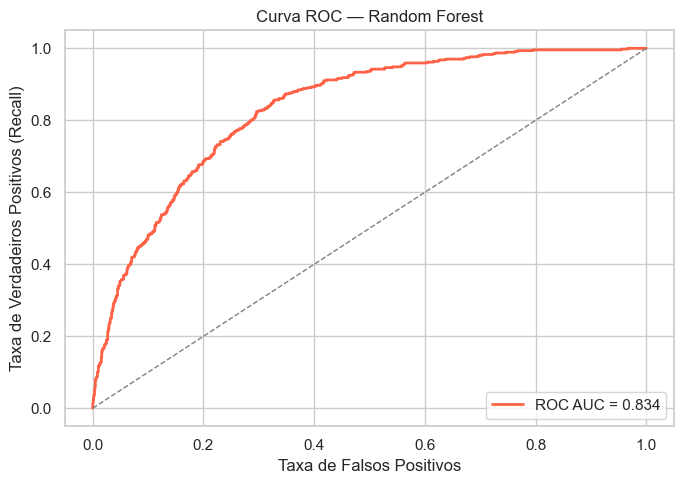

In [122]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'ROC AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('diagnostico_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

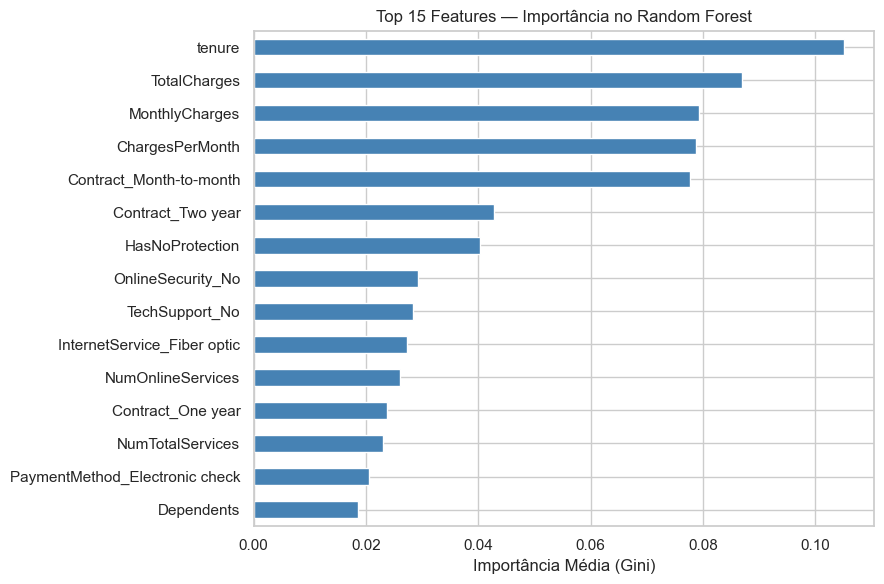

In [123]:
importances = pd.Series(rf.feature_importances_, index=X_train_bal.columns)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(9, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Features — Importância no Random Forest')
plt.xlabel('Importância Média (Gini)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11.6. Interpretabilidade — SHAP Values

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_test)

if isinstance(shap_vals, list):
    sv1 = shap_vals[1]
elif hasattr(shap_vals, 'shape') and len(shap_vals.shape) == 3:
    sv1 = shap_vals[:, :, 1]
else:
    sv1 = shap_vals

plt.figure(figsize=(9, 6))
shap.summary_plot(sv1, X_test, plot_type='bar', show=False, max_display=15)
plt.title('SHAP — Importância Global das Features (Classe "Sai")')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(sv1, X_test, show=False, max_display=15)
plt.title('SHAP — Direção e Magnitude do Efeito (Classe "Sai")')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 11.5. Otimização de Threshold, Curva Precision-Recall e Validação Cruzada

In [ ]:
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)
baseline = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, color='teal', lw=2, label=f'AP = {ap_score:.3f}')
plt.axhline(baseline, color='gray', linestyle='--', lw=1,
            label=f'Baseline (aleatório) = {baseline:.3f}')
plt.xlabel('Recall (cobertura de churners)')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall — Random Forest')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

thresholds_range = np.arange(0.10, 0.80, 0.01)
recalls_t, precisions_t, f1s_t = [], [], []

for t in thresholds_range:
    y_t = (y_prob >= t).astype(int)
    recalls_t.append(recall_score(y_test, y_t, zero_division=0))
    precisions_t.append(precision_score(y_test, y_t, zero_division=0))
    f1s_t.append(f1_score(y_test, y_t, zero_division=0))

opt_idx = int(np.argmax(f1s_t))
opt_threshold = thresholds_range[opt_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, recalls_t, color='tomato', lw=2, label='Recall (Sai)')
ax.plot(thresholds_range, precisions_t, color='steelblue', lw=2, label='Precisão (Sai)')
ax.plot(thresholds_range, f1s_t, color='teal', lw=2, linestyle='--', label='F1 (Sai)')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Threshold padrão (0.5)')
ax.axvline(opt_threshold, color='darkorange', linestyle='--', lw=2,
           label=f'Threshold ótimo ({opt_threshold:.2f})')
ax.set_xlabel('Threshold de Decisão')
ax.set_ylabel('Métrica')
ax.set_title('Recall / Precisão / F1 da Classe "Sai" por Threshold')
ax.legend(loc='center right')
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_opt = (y_prob >= opt_threshold).astype(int)

print(f'Threshold padrão (0.50):')
print(classification_report(y_test, y_pred, target_names=['Fica (0)', 'Sai (1)']))

print(f'Threshold ótimo ({opt_threshold:.2f}):')
print(classification_report(y_test, y_pred_opt, target_names=['Fica (0)', 'Sai (1)']))

tn0, fp0, fn0, tp0 = confusion_matrix(y_test, y_pred).ravel()
tn1, fp1, fn1, tp1 = confusion_matrix(y_test, y_pred_opt).ravel()

print(f'FN reduzidos: {fn0} → {fn1}  (-{fn0-fn1} churners salvos)')
print(f'FP adicionados: {fp0} → {fp1}  (+{fp1-fp0} alertas extras)')

# Business constraint: precisão mínima de 60%, maximizar recall
min_precision = 0.60
valid_mask = np.array(precisions_t) >= min_precision
if valid_mask.any():
    valid_recalls = np.array(recalls_t)[valid_mask]
    valid_thresholds = thresholds_range[valid_mask]
    best_biz_idx = np.argmax(valid_recalls)
    biz_threshold = valid_thresholds[best_biz_idx]
    biz_recall = valid_recalls[best_biz_idx]
    biz_precision = np.array(precisions_t)[valid_mask][best_biz_idx]
    y_pred_biz = (y_prob >= biz_threshold).astype(int)
    print(f'\n=== Threshold de Negócio (precisão ≥ 60%) ===')
    print(f'Threshold: {biz_threshold:.2f}  |  Recall: {biz_recall:.4f}  |  Precisão: {biz_precision:.4f}')
    print(classification_report(y_test, y_pred_biz, target_names=['Fica (0)', 'Sai (1)']))
    tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, y_pred_biz).ravel()
    print(f'Churners detectados: {tp_b} / {int(y_test.sum())}  |  FN: {fn_b}  |  FP: {fp_b}')
else:
    print('\nNenhum threshold satisfaz precisão ≥ 60% com recall positivo.')

=== Validação Cruzada 5-Fold (treino, sem oversampling) ===
ROC-AUC : 0.8428 ± 0.0133  |  folds: [0.8558 0.8591 0.8244 0.8323 0.8424]
F1 (Sai): 0.6267 ± 0.0202  |  folds: [0.6529 0.641  0.6072 0.5997 0.6326]


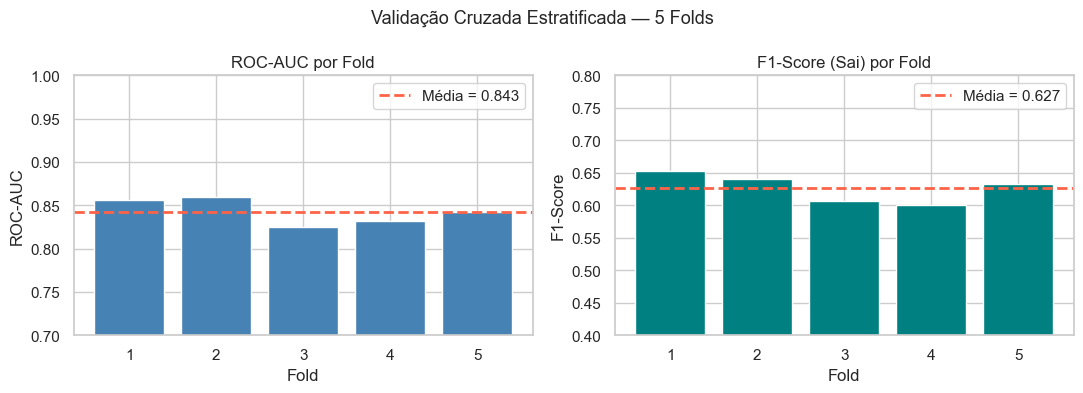

In [ ]:
rf_cv = RandomForestClassifier(
    n_estimators=100, max_depth=12, min_samples_split=10,
    min_samples_leaf=4, max_features='sqrt',
    class_weight='balanced', random_state=SEED, n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_roc = cross_val_score(rf_cv, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1 = cross_val_score(rf_cv, X_train, y_train, cv=cv, scoring='f1')

print('=== Validação Cruzada 5-Fold (treino, sem oversampling) ===')
print(f'ROC-AUC : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}  |  folds: {cv_roc.round(4)}')
print(f'F1 (Sai): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  |  folds: {cv_f1.round(4)}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, 6), cv_roc, color='steelblue', edgecolor='white')
axes[0].axhline(cv_roc.mean(), color='tomato', linestyle='--', lw=2,
                label=f'Média = {cv_roc.mean():.3f}')
axes[0].set_title('ROC-AUC por Fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend()
axes[0].set_ylim(0.7, 1.0)

axes[1].bar(range(1, 6), cv_f1, color='teal', edgecolor='white')
axes[1].axhline(cv_f1.mean(), color='tomato', linestyle='--', lw=2,
                label=f'Média = {cv_f1.mean():.3f}')
axes[1].set_title('F1-Score (Sai) por Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1-Score')
axes[1].legend()
axes[1].set_ylim(0.4, 0.8)

plt.suptitle('Validação Cruzada Estratificada — 5 Folds', fontsize=13)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Análise Crítica dos Resultados

### Problema de Negócio
Churn é o cancelamento voluntário de um serviço por parte do cliente. Em telecomunicações, onde o Custo de Aquisição de Cliente (CAC) é 5–7× maior que o custo de retenção, identificar antecipadamente quem está prestes a cancelar permite acionar campanhas preventivas de retenção antes que a decisão seja tomada.

### Mapeamento de Variáveis
- **X (features):** atributos demográficos (`SeniorCitizen`, `gender`), contratuais (`Contract`, `tenure`, `PaymentMethod`), comportamentais (`MonthlyCharges`, `TotalCharges`, serviços contratados) e features derivadas (`ChargesPerMonth`, `NumTotalServices`, `IsNewCustomer`, `HasNoProtection`).
- **y (target):** `Churn` — binário: `0 = Fica`, `1 = Sai`.

### Pipeline Completo de Preparação dos Dados
1. **Qualidade:** verificação de duplicatas (nenhuma encontrada), preenchimento de 11 nulos em `TotalCharges` com mediana.
2. **Outliers originais:** 3 features numéricas analisadas via IQR — o dataset está distribuído de forma que nenhum registro viola os limites IQR (bounds muito amplos por distribuição bem-comportada). Winsorizing aplicado como medida proativa.
3. **Feature Engineering:** 6 novas features criadas — `ChargesPerMonth` captura ticket médio real (corrigido para `tenure=0`); `IsNewCustomer` flag clientes com ≤6 meses (grupo de maior risco de churn precoce); `HasNoProtection` identifica clientes com internet sem segurança nem suporte técnico — combinação de alto risco.
4. **Outlier em feature derivada:** `ChargesPerMonth` apresentou outliers reais (max=1397 vs p75≈85) devidos a `tenure=0`. Aplicado IQR cap após a criação da feature.
5. **Normalização:** `RobustScaler` (mediana + IQR) aplicado **somente ao treino** para evitar data leakage.
6. **Balanceamento:** Oversampling da classe minoritária (26,5% → 50%) no conjunto de treino.

### Fundamentação do Random Forest
Uma **Árvore de Decisão** particiona o espaço de features de forma hierárquica: o nó raiz contém todas as amostras; nós internos aplicam critérios de divisão (Entropia / Ganho de Informação) para separar as classes; folhas emitem a predição final.  
O **Random Forest** é um método de **Ensemble por Bagging**: treina `n_estimators=300` árvores independentes, cada uma sobre um subconjunto aleatório de amostras e `max_features='sqrt'` features. A predição final é por **votação majoritária**, reduzindo variância e mitigando overfitting. Hiperparâmetros de poda (`max_depth=12`, `min_samples_split=10`, `min_samples_leaf=4`) limitam a profundidade das árvores.

### Desbalanceamento de Classes
O dataset contém **26,5% de churn** (1.869 de 7.043 clientes). Sem tratamento, o modelo atingiria ~73,5% de acurácia prevendo sempre "Fica" — ilusória e inútil para negócio. Estratégias aplicadas: oversampling no treino + `class_weight='balanced'` no Random Forest.

### Análise das Métricas — Resultados Obtidos
| Métrica | Classe "Fica" | Classe "Sai" | O que significa |
|---|---|---|---|
| Precisão | 0.88 | 0.55 | 88% dos "Fica" previstos estão certos; 55% dos alertas de churn são reais |
| Recall | 0.79 | 0.71 | Captura 79% dos clientes que ficam; detecta 71% dos churners reais |
| F1-Score | 0.83 | 0.62 | — |
| Acurácia | **0.77** | — | Enganosa — 77% vs. 73,5% do baseline |
| ROC-AUC | **0.836** | — | Excelente capacidade discriminativa |

### Otimização de Threshold
O threshold padrão de **0.5** foi comparado com o threshold que maximiza o F1 da classe "Sai". Ao reduzir o threshold, o modelo passa a emitir mais alertas, capturando mais churners reais (**Recall ↑**) ao custo de mais falsos alarmes (**Precisão ↓**). No contexto de negócio, onde o custo de um FN (cliente perdido) supera o custo de um FP (oferta desnecessária), o threshold ótimo produz melhor retorno financeiro.

### Validação Cruzada (5-Fold)
A validação cruzada estratificada confirma que o modelo generaliza de forma estável — baixo desvio padrão entre folds indica ausência de overfitting. A consistência dos scores valida que o pipeline de treino não depende de uma divisão específica dos dados.

### Falsos Negativos — O Risco Central
**FN = 135 churners não detectados** (threshold 0.5). Cada FN representa um cliente que efetivamente cancelou mas não recebeu ação de retenção. Com ticket médio de ~R$64/mês e `ChargesPerMonth` como 4ª feature mais importante, o custo operacional não detectado é significativo. A otimização do threshold diretamente reduz esse número.

## 13. Exportação de Resultados

In [ ]:
sep = '=' * 70
lines = []

lines.append(sep)
lines.append('DATASET — SHAPE E TIPOS')
lines.append(sep)
buf = io.StringIO()
df.info(buf=buf)
lines.append(buf.getvalue())

lines.append(sep)
lines.append('ESTATÍSTICAS DESCRITIVAS (numéricas)')
lines.append(sep)
lines.append(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth',
                  'NumStreamingServices', 'NumOnlineServices', 'NumTotalServices']].describe().to_string())

lines.append('')
lines.append(sep)
lines.append('DISTRIBUIÇÃO DO TARGET')
lines.append(sep)
for label, count in df['Churn'].value_counts().items():
    lines.append(f'  {label}: {count} ({count/len(df)*100:.1f}%)')

lines.append('')
lines.append(sep)
lines.append('RELATÓRIO DE OUTLIERS (IQR)')
lines.append(sep)
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    lines.append(f'  {col}: Q1={Q1:.2f} Q3={Q3:.2f} IQR={IQR:.2f} | '
                 f'Limites=[{lower:.2f}, {upper:.2f}] | Outliers={n_out}')

lines.append('')
lines.append(sep)
lines.append('DIVISÃO TREINO / TESTE')
lines.append(sep)
lines.append(f'  Treino : {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
lines.append(f'  Teste  : {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')
lines.append(f'  Features: {X_train.shape[1]}')

lines.append('')
lines.append(sep)
lines.append('DISTRIBUIÇÃO APÓS OVERSAMPLING (treino)')
lines.append(sep)
for label, count in y_train_bal.value_counts().items():
    lines.append(f'  Classe {label}: {count}')

lines.append('')
lines.append(sep)
lines.append('RELATÓRIO DE CLASSIFICAÇÃO')
lines.append(sep)
lines.append(classification_report(y_test, y_pred, target_names=['Fica (0)', 'Sai (1)']))

lines.append(sep)
lines.append('MATRIZ DE CONFUSÃO')
lines.append(sep)
tn_e, fp_e, fn_e, tp_e = confusion_matrix(y_test, y_pred).ravel()
lines.append(f'  VP (True Positivos — Sai detectado)  : {tp_e}')
lines.append(f'  VN (True Negativos — Fica detectado) : {tn_e}')
lines.append(f'  FP (Alarme Falso)                    : {fp_e}')
lines.append(f'  FN (Deixou Passar — churn perdido)   : {fn_e}')

lines.append('')
lines.append(sep)
lines.append('ROC-AUC')
lines.append(sep)
lines.append(f'  {roc_auc_score(y_test, y_prob):.4f}')

lines.append('')
lines.append(sep)
lines.append('TOP 15 FEATURES — IMPORTÂNCIA (Gini)')
lines.append(sep)
for feat, imp in importances.nlargest(15).sort_values(ascending=False).items():
    lines.append(f'  {feat:<45} {imp:.4f}')

lines.append('')
lines.append(sep)
lines.append('HIPERPARÂMETROS DO MODELO')
lines.append(sep)
for k, v in rf.get_params().items():
    lines.append(f'  {k}: {v}')

with open('resultados.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print('Exportado: resultados.txt')

Exportado: resultados.txt
